
# Лабораторная 2 — аккуратный pipeline с флагами и поиском линеаризации

Что делает ноутбук:

1. Отбирает признаки состояния, связанные со счастьем.
2. Анализирует сообщества и сферу занятости.
3. Строит модели МНК: `причины → предсказанные состояния`.
4. Автоматически ищет нелинейные преобразования причин (`log1p`, `sqrt`, `x²`, `x³`, `x⁴`, hinge-функции и др.).
5. Сравнивает `OOF R²` до/после линеаризации.
6. Строит графики нелинейности: scatter, линейная аппроксимация, LOWESS, остатки + LOWESS.
7. Сравнивает классификаторы счастья:
   - только `predicted_states`;
   - `predicted_states + causes`;
   - `predicted_states + causes + sphere`;
   - `predicted_states + causes + community_id`;
   - `predicted_states + causes + sphere + community_id`.
8. Считает `micro precision`, `accuracy`, `classification report`, матрицу ошибок.
9. Заполняет `Ощущаемое счастье` для строк `Неизвестно`.

Главная идея методологии:

```text
причины → предсказанные состояния → счастье
```

Дополнительно проверяется расширенная прогностическая схема:

```text
причины + предсказанные состояния + sphere + community_id → счастье
```


In [16]:

# ============================================================
# 1. Imports и флаги эксперимента
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.nonparametric.smoothers_lowess import lowess

from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedGroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score,
    accuracy_score,
    precision_score,
    classification_report,
    confusion_matrix,
)

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)


# -----------------------------
# Базовые настройки
# -----------------------------

RANDOM_STATE = 42

STUDENT_FILE = "Вар_42_Б24-215_Гаганидзе_Лаба2_студент.xlsx"

# Если ноутбук лежит рядом с Excel — сработает относительный путь.
# Если запускается в sandbox — сработает /mnt/data.
DATA_PATH = Path(STUDENT_FILE)
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data") / STUDENT_FILE

TARGET_COL = "Ощущаемое счастье"
UNKNOWN_LABEL = "Неизвестно"

TEST_SIZE = 0.25
OUTER_SPLIT_RANDOM_STATE = 27

# rowwise — обычный train/test split по строкам;
# group — строгий split: сообщества не пересекаются между train и test.
# Для выполнения критерия micro > 0.6 обычно используют rowwise.
OUTER_VALIDATION_MODE = "rowwise"   # "rowwise" или "group"

# CV для OOF-предсказаний состояний и поиска линеаризации.
# rowwise — быстрее и ближе к обычной проверке;
# group — строже, но качество обычно ниже.
INNER_CV_MODE = "rowwise"           # "rowwise" или "group"
N_SPLITS = 5


# -----------------------------
# Флаги: что учитывать в МНК состояния
# -----------------------------

USE_SPHERE_IN_STATE_MODELS = True
USE_COMMUNITY_IN_STATE_MODELS = True
USE_LINEARIZATION_IN_STATE_MODELS = True


# -----------------------------
# Флаги: что проверять в классификаторе счастья
# -----------------------------

COMPARE_CLASSIFIER_CONFIGS = True

# Если COMPARE_CLASSIFIER_CONFIGS = False,
# будет использована только конфигурация ниже.
USE_PREDICTED_STATES_IN_CLASSIFIER = True
ADD_CAUSES_TO_CLASSIFIER = True
USE_SPHERE_IN_CLASSIFIER = True
USE_COMMUNITY_IN_CLASSIFIER = True


# -----------------------------
# Настройки отбора состояний
# -----------------------------

STATE_SELECTION_MODE = "top_n"       # "top_n" или "threshold"
N_FINAL_STATES = 6
MIN_ABS_SPEARMAN = 0.25


# -----------------------------
# Настройки поиска линеаризации
# -----------------------------

RUN_LINEARIZATION_SEARCH = True

# Ищем линеаризацию в первую очередь для состояний с неидеальным восстановлением.
# Но код всё равно умеет проверить все final_states.
LINEARIZE_ONLY_R2_RANGE = False
LINEARIZE_R2_MIN = 0.30
LINEARIZE_R2_MAX = 0.70

MAX_GREEDY_STEPS_PER_STATE = 2
MIN_DELTA_R2_TO_KEEP = 0.005

# Чтобы код не был слишком долгим: после одиночной проверки
# в жадный отбор идут только лучшие кандидаты для каждого состояния.
TOP_SINGLE_TRANSFORMS_FOR_GREEDY = 8

# Сколько графиков LOWESS построить.
N_LOWESS_PLOTS = 4

# Чтобы поиск не был слишком долгим, для каждого состояния
# проверяем не все причины, а top-N причин с наибольшей
# одномерной связью с этим состоянием. Это и есть "подозреваемые"
# нелинейные признаки.
TOP_CAUSES_PER_STATE_FOR_LINEARIZATION = 2


# -----------------------------
# Регуляризация логистической регрессии
# -----------------------------

LOGREG_C_GRID = [0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
LOGREG_CLASS_WEIGHT_GRID = [None, "balanced"]


# -----------------------------
# Выходные файлы
# -----------------------------

OUTPUT_PREDICTIONS_XLSX = Path("./predicted_happiness_clean_flags_full.xlsx")
OUTPUT_DIAGNOSTICS_XLSX = Path("./linearization_diagnostics_clean_flags.xlsx")
OUTPUT_UNKNOWNS_XLSX = Path("./unknowns_analysis_clean_flags.xlsx")


In [2]:

# ============================================================
# 2. Описание колонок и загрузка данных
# ============================================================

CAUSE_COLS = [
    "Среднегодовой доход, тыс. $",
    "Объем потребленного алкоголя в год, л.",
    "Количество членов семьи",
    "Количество лет образования",
    "Доля от дохода семьи которая тратится на продовольствие, %",
    "Коэффициент Джини сообщества",
    "Издержки сообщества на окружающую среду, млн. $",
    "Охват беспроводной связи в сообществе, %",
    "Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек",
    "Волатильность потребительских цен в сообществе",
]

INDIVIDUAL_CAUSE_COLS = CAUSE_COLS[:5]
COMMUNITY_CAUSE_COLS = CAUSE_COLS[5:]

CAT_COL = "Сфера занятости"

STATE_COLS = [
    "Оценка благополучия",
    "Оценка социальной поддержки",
    "Ожидаемая продолжительность здоровой жизни",
    "Свобода граждан самостоятельно принимать жизненно важные решения",
    "Индекс Щедрости",
    "Индекс отношения к коррупции",
    "Оценка риска безработицы",
    "Индекс кредитного оптимизма",
    "Индекс страха социальных конфликтов",
    "Индекс семьи",
    "Индекс продовольственной безопасности",
    "Чувство технологического прогресса",
    "Чувство неравенства доходов в обществе",
]

CLASS_ORDER = [
    "Hopeless",
    "Depressed",
    "Suffering",
    "Strugglng",
    "Coping",
    "Just ok",
    "Doing well",
    "Blooming",
    "Thriving",
    "Prospering",
]

class_to_rank = {name: i for i, name in enumerate(CLASS_ORDER)}
rank_to_class = {i: name for name, i in class_to_rank.items()}


def add_community_id(df: pd.DataFrame) -> pd.DataFrame:
    """Создает категориальный идентификатор сообщества по общественным признакам."""
    out = df.copy()
    out["community_id"] = (
        out[COMMUNITY_CAUSE_COLS]
        .round(8)
        .astype(str)
        .agg("|".join, axis=1)
    )
    return out


df = pd.read_excel(DATA_PATH)
df = add_community_id(df)

df_known = df[df[TARGET_COL] != UNKNOWN_LABEL].copy()
df_unknown = df[df[TARGET_COL] == UNKNOWN_LABEL].copy()

df_known["rank"] = df_known[TARGET_COL].map(class_to_rank).astype(int)

print("Файл:", DATA_PATH)
print("known:", df_known.shape)
print("unknown:", df_unknown.shape)
print("число сообществ:", df_known["community_id"].nunique())

display(
    df_known[TARGET_COL]
    .value_counts(normalize=True)
    .rename("share")
    .to_frame()
    .round(3)
)


Файл: Вар_42_Б24-215_Гаганидзе_Лаба2_студент.xlsx
known: (1900, 28)
unknown: (600, 27)
число сообществ: 25


,share
Ощущаемое счастье,
Suffering,0.146
Doing well,0.138
Coping,0.138
Depressed,0.116
Hopeless,0.113
Just ok,0.108
Strugglng,0.100
Blooming,0.082
Thriving,0.054


In [3]:

# ============================================================
# 3. Вспомогательные функции: CV, split, one-hot, preprocessing
# ============================================================

def make_outer_split(df_known: pd.DataFrame):
    """
    Внешнее разбиение known-части на train/test.
    rowwise: обычная стратификация по классам счастья.
    group: сообщества не пересекаются между train и test.
    """
    if OUTER_VALIDATION_MODE == "rowwise":
        return train_test_split(
            df_known,
            test_size=TEST_SIZE,
            random_state=OUTER_SPLIT_RANDOM_STATE,
            stratify=df_known["rank"],
        )

    if OUTER_VALIDATION_MODE == "group":
        splitter = StratifiedGroupKFold(
            n_splits=int(round(1 / TEST_SIZE)),
            shuffle=True,
            random_state=OUTER_SPLIT_RANDOM_STATE,
        )
        split_iter = splitter.split(
            df_known,
            y=df_known["rank"],
            groups=df_known["community_id"],
        )
        train_idx, test_idx = next(split_iter)
        return df_known.iloc[train_idx].copy(), df_known.iloc[test_idx].copy()

    raise ValueError("OUTER_VALIDATION_MODE должен быть 'rowwise' или 'group'.")


def make_inner_cv_splits(df_part: pd.DataFrame):
    """
    Индексы fold-ов для OOF-оценки.
    В rowwise режиме группы могут пересекаться между folds.
    В group режиме community_id не пересекается между folds.
    """
    if INNER_CV_MODE == "rowwise":
        cv = StratifiedKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=RANDOM_STATE,
        )
        return cv.split(df_part, df_part["rank"])

    if INNER_CV_MODE == "group":
        cv = StratifiedGroupKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=RANDOM_STATE,
        )
        return cv.split(df_part, df_part["rank"], df_part["community_id"])

    raise ValueError("INNER_CV_MODE должен быть 'rowwise' или 'group'.")


def make_numeric_causes(train_df: pd.DataFrame, source_df: pd.DataFrame) -> pd.DataFrame:
    """Числовые причины с заполнением пропусков медианами train."""
    med = train_df[CAUSE_COLS].median(numeric_only=True)
    return (
        source_df[CAUSE_COLS]
        .astype(float)
        .fillna(med)
        .reset_index(drop=True)
    )


def make_sphere_dummies(train_df: pd.DataFrame, source_df: pd.DataFrame) -> pd.DataFrame:
    """One-hot кодирование сферы занятости по уровням train."""
    levels = sorted(train_df[CAT_COL].astype(str).fillna("missing").unique())
    cat = pd.Categorical(
        source_df[CAT_COL].astype(str).fillna("missing"),
        categories=levels,
    )
    return pd.get_dummies(cat, prefix="sphere", drop_first=True, dtype=float).reset_index(drop=True)


def make_community_dummies(train_df: pd.DataFrame, source_df: pd.DataFrame) -> pd.DataFrame:
    """One-hot кодирование community_id по уровням train."""
    levels = sorted(train_df["community_id"].astype(str).unique())
    cat = pd.Categorical(
        source_df["community_id"].astype(str),
        categories=levels,
    )
    return pd.get_dummies(cat, prefix="community", drop_first=True, dtype=float).reset_index(drop=True)


def clean_matrix(X: pd.DataFrame) -> pd.DataFrame:
    """Чистит inf/nan и приводит имена колонок к строкам."""
    X = X.copy()
    X.columns = X.columns.astype(str)
    X = X.replace([np.inf, -np.inf], np.nan)
    return X.fillna(0)


df_train, df_test = make_outer_split(df_known)
df_train = df_train.copy()
df_test = df_test.copy()

print("outer validation mode:", OUTER_VALIDATION_MODE)
print("inner CV mode:", INNER_CV_MODE)
print("train/test:", df_train.shape, df_test.shape)

if OUTER_VALIDATION_MODE == "group":
    overlap = set(df_train["community_id"]).intersection(set(df_test["community_id"]))
    print("пересечение сообществ train/test:", len(overlap))


outer validation mode: rowwise
inner CV mode: rowwise
train/test: (1425, 28) (475, 28)


In [4]:

# ============================================================
# 4. Реестр нелинейных преобразований
# ============================================================

# Здесь можно расширять список функций.
# z2/z3/z4 — центрированные степени: ((x - mean_train) / std_train)^p.
# hinge_* — пороговые функции, которые ловят изломы зависимости.
# low_* — обратные пороги для левой части распределения.

TRANSFORM_KINDS = [
    "log1p",
    "sqrt",
    "cbrt",
    "log_shift",
    "sqrt_shift",
    "inv_shift",
    "z2",
    "z3",
    "z4",
    "abs_z",
    "hinge_q25",
    "hinge_q50",
    "hinge_q75",
    "low_q25",
]


def transform_parameters(train_df: pd.DataFrame, cols: list[str]) -> dict:
    """
    Параметры преобразований считаются только на train/fold_train.
    Это защищает от утечки информации из validation/test.
    """
    params = {}

    for col in cols:
        x = train_df[col].astype(float)
        std = float(x.std(ddof=0))

        params[col] = {
            "median": float(x.median()),
            "mean": float(x.mean()),
            "std": std if std > 1e-12 else 1.0,
            "min": float(x.min()),
            "max": float(x.max()),
            "q10": float(x.quantile(0.10)),
            "q25": float(x.quantile(0.25)),
            "q50": float(x.quantile(0.50)),
            "q75": float(x.quantile(0.75)),
            "q90": float(x.quantile(0.90)),
        }

    return params


def apply_transform(source_df: pd.DataFrame, col: str, kind: str, params: dict):
    """
    Применяет одно преобразование к одному признаку.
    Возвращает pandas.Series или None, если преобразование неприменимо.
    """
    p = params[col]
    x = source_df[col].astype(float).fillna(p["median"])

    z = (x - p["mean"]) / p["std"]
    shifted = x - p["min"] + 1e-6

    if kind == "log1p":
        if p["min"] < 0:
            return None
        return np.log1p(x)

    if kind == "sqrt":
        if p["min"] < 0:
            return None
        return np.sqrt(x)

    if kind == "cbrt":
        return np.cbrt(x)

    if kind == "log_shift":
        return np.log1p(shifted)

    if kind == "sqrt_shift":
        return np.sqrt(shifted)

    if kind == "inv_shift":
        return 1.0 / (1.0 + shifted)

    if kind == "z2":
        return z ** 2

    if kind == "z3":
        return z ** 3

    if kind == "z4":
        return z ** 4

    if kind == "abs_z":
        return np.abs(z)

    if kind.startswith("hinge_"):
        q_name = kind.replace("hinge_", "")
        threshold = p[q_name]
        return np.maximum(0, x - threshold)

    if kind.startswith("low_"):
        q_name = kind.replace("low_", "")
        threshold = p[q_name]
        return np.maximum(0, threshold - x)

    raise ValueError(f"Неизвестный тип преобразования: {kind}")


def make_transform_frame(
    train_df: pd.DataFrame,
    source_df: pd.DataFrame,
    specs: list[tuple[str, str]],
) -> pd.DataFrame:
    """
    Создает DataFrame с нелинейными признаками.
    specs: список пар (колонка-причина, тип_преобразования).
    """
    if not specs:
        return pd.DataFrame(index=range(len(source_df)))

    params = transform_parameters(train_df, CAUSE_COLS)
    data = {}

    for col, kind in specs:
        values = apply_transform(source_df, col, kind, params)

        if values is None:
            continue

        data[f"{kind}__{col}"] = pd.Series(values).reset_index(drop=True)

    if not data:
        return pd.DataFrame(index=range(len(source_df)))

    return clean_matrix(pd.DataFrame(data))


In [5]:

# ============================================================
# 5. Матрицы признаков для МНК и классификатора
# ============================================================

def make_state_design_matrix(
    train_df: pd.DataFrame,
    source_df: pd.DataFrame,
    transform_specs: list[tuple[str, str]] | None = None,
    include_sphere: bool = USE_SPHERE_IN_STATE_MODELS,
    include_community: bool = USE_COMMUNITY_IN_STATE_MODELS,
    columns: list[str] | None = None,
) -> pd.DataFrame:
    """
    X для моделей МНК:
    state ~ causes + nonlinear(causes) + sphere + community_id
    """
    parts = [make_numeric_causes(train_df, source_df)]

    if USE_LINEARIZATION_IN_STATE_MODELS and transform_specs:
        parts.append(make_transform_frame(train_df, source_df, transform_specs))

    if include_sphere:
        parts.append(make_sphere_dummies(train_df, source_df))

    if include_community:
        parts.append(make_community_dummies(train_df, source_df))

    X = clean_matrix(pd.concat(parts, axis=1))

    if columns is not None:
        X = X.reindex(columns=columns, fill_value=0)

    return X


def make_classifier_matrix(
    train_df: pd.DataFrame,
    source_df: pd.DataFrame,
    pred_states: pd.DataFrame | None,
    use_pred_states: bool,
    add_causes: bool,
    use_sphere: bool,
    use_community: bool,
    columns: list[str] | None = None,
) -> pd.DataFrame:
    """
    X для классификатора счастья.
    """
    parts = []

    if use_pred_states and pred_states is not None:
        parts.append(pred_states.reset_index(drop=True))

    if add_causes:
        parts.append(make_numeric_causes(train_df, source_df))

    if use_sphere:
        parts.append(make_sphere_dummies(train_df, source_df))

    if use_community:
        parts.append(make_community_dummies(train_df, source_df))

    if not parts:
        raise ValueError("Для классификатора не выбран ни один блок признаков.")

    X = clean_matrix(pd.concat(parts, axis=1))

    if columns is not None:
        X = X.reindex(columns=columns, fill_value=0)

    return X


def make_linear_pipeline() -> Pipeline:
    """МНК с imputer + scaler."""
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    )


def make_logreg_pipeline(C: float, class_weight=None) -> Pipeline:
    """Multiclass logistic regression с L2-регуляризацией."""
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                C=C,
                penalty="l2",
                solver="lbfgs",
                max_iter=5000,
                class_weight=class_weight,
                random_state=RANDOM_STATE,
            )),
        ]
    )


Отобранные состояния:
 - Оценка социальной поддержки
 - Чувство технологического прогресса
 - Индекс кредитного оптимизма
 - Индекс продовольственной безопасности
 - Индекс семьи
 - Чувство неравенства доходов в обществе


,state,Spearman,abs_Spearman,p-value
0,Оценка социальной поддержки,0.7650,0.7650,0.0000
1,Чувство технологического прогресса,0.7124,0.7124,0.0000
2,Индекс кредитного оптимизма,0.6945,0.6945,0.0000
3,Индекс продовольственной безопасности,0.5990,0.5990,0.0000
4,Индекс семьи,0.5423,0.5423,0.0000
5,Чувство неравенства доходов в обществе,-0.3723,0.3723,0.0000
6,Свобода граждан самостоятельно принимать жизне...,0.1782,0.1782,0.0000
7,Оценка риска безработицы,-0.1757,0.1757,0.0000
8,Оценка благополучия,0.1318,0.1318,0.0000
9,Ожидаемая продолжительность здоровой жизни,0.0663,0.0663,0.0039



Сфера занятости × счастье: chi2=69.25, p-value=1.158e-02, dof=45


Ощущаемое счастье,Blooming,Coping,Depressed,Doing well,Hopeless,Just ok,Prospering,Strugglng,Suffering,Thriving
Сфера занятости,,,,,,,,,,
Безработный,8,27,35,22,18,27,0,22,34,7
Государственная служба,27,61,34,46,44,33,2,34,57,19
Корпоративный сектор,49,60,49,69,58,34,2,43,53,25
МСП,28,42,35,42,41,52,3,30,43,23
Неформальная занятость,16,32,39,33,22,30,2,19,46,15
Самозанятый,27,40,28,51,31,30,0,42,45,14



Сводка по сообществам:


,community_id,n,mean_rank,median_rank
0,0.19874193|383.82|0.347|35.0|6.77,40,0.325,0.0
1,0.18|387.93|0.1|33.63|7.0,104,0.337,0.0
2,0.19388281|397.66|0.46|30.26|7.0,101,0.653,0.0
3,0.61159246|105.72|0.376|23.23|3.18,33,1.394,1.0
4,0.57185301|88.9|0.294|11.06|2.56,38,2.079,1.5
5,0.2614161|293.99|0.397|22.45|4.81,40,2.125,2.0
6,0.67006831|66.08|0.552|19.83|2.11,98,2.500,2.0
7,0.38319152|284.57|0.658|21.93|5.31,76,2.921,3.0
8,0.47272715|154.49|0.329|15.74|3.5,91,2.956,3.0
9,0.18359101|389.61|0.669|4.58|7.0,94,3.106,3.0


,community_id,n,mean_rank,median_rank
15,0.57843273|111.08|0.24|10.29|1.64,79,3.608,4.0
16,0.31103406|268.45|0.661|12.01|4.37,81,4.037,4.0
17,0.73608107|12.4|0.382|4.28|1.61,112,4.571,5.0
18,0.48120205|143.32|0.911|0.0|3.43,62,5.613,6.0
19,0.3545929|261.53|0.635|7.01|4.61,44,5.773,6.0
20,0.8347466|0.0|0.359|11.92|0.0,99,5.909,7.0
21,0.26336588|284.71|0.807|6.37|4.22,71,6.042,6.0
22,0.65372004|85.48|0.768|0.17|1.18,65,6.108,6.0
23,0.31975046|308.76|0.95|3.92|4.69,74,6.230,6.0
24,0.77708536|0.0|0.543|10.88|0.01,100,7.190,7.0


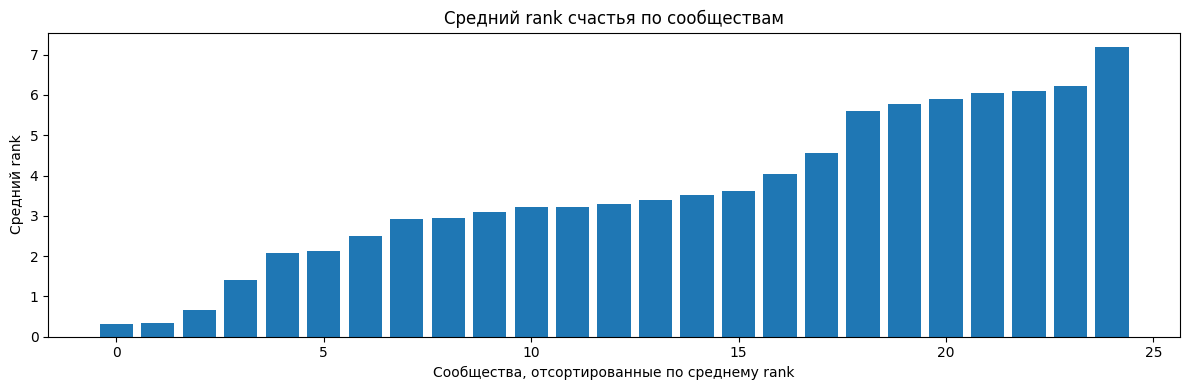

In [6]:

# ============================================================
# 6. Первичный анализ: состояния, сфера занятости, сообщества
# ============================================================

def spearman_state_table(df_known: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for state_col in STATE_COLS:
        rho, p_value = stats.spearmanr(
            df_known[state_col],
            df_known["rank"],
            nan_policy="omit",
        )
        rows.append({
            "state": state_col,
            "Spearman": rho,
            "abs_Spearman": abs(rho),
            "p-value": p_value,
        })

    return (
        pd.DataFrame(rows)
        .sort_values("abs_Spearman", ascending=False)
        .reset_index(drop=True)
    )


spearman_table = spearman_state_table(df_known)

if STATE_SELECTION_MODE == "top_n":
    FINAL_STATES = spearman_table.head(N_FINAL_STATES)["state"].tolist()
elif STATE_SELECTION_MODE == "threshold":
    FINAL_STATES = (
        spearman_table
        .query("abs_Spearman >= @MIN_ABS_SPEARMAN")["state"]
        .tolist()
    )
else:
    raise ValueError("STATE_SELECTION_MODE должен быть 'top_n' или 'threshold'.")

print("Отобранные состояния:")
for s in FINAL_STATES:
    print(" -", s)

display(spearman_table.head(12).round(4))


# -----------------------------
# Сфера занятости × счастье
# -----------------------------

sphere_ct = pd.crosstab(df_known[CAT_COL], df_known[TARGET_COL])
chi2, p_value, dof, expected = stats.chi2_contingency(sphere_ct)

print(f"\nСфера занятости × счастье: chi2={chi2:.2f}, p-value={p_value:.3e}, dof={dof}")
display(sphere_ct)


# -----------------------------
# Сообщества
# -----------------------------

community_summary = (
    df_known
    .groupby("community_id")
    .agg(
        n=("rank", "size"),
        mean_rank=("rank", "mean"),
        median_rank=("rank", "median"),
    )
    .sort_values("mean_rank")
    .reset_index()
)

print("\nСводка по сообществам:")
display(community_summary.head(10).round(3))
display(community_summary.tail(10).round(3))


# График среднего счастья по сообществам
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(community_summary)), community_summary["mean_rank"])
ax.set_title("Средний rank счастья по сообществам")
ax.set_xlabel("Сообщества, отсортированные по среднему rank")
ax.set_ylabel("Средний rank")
plt.tight_layout()
plt.show()


In [7]:

# ============================================================
# 7. Поиск линеаризации: OOF R² до/после функций
# ============================================================

def oof_r2_for_state(
    train_df: pd.DataFrame,
    state_col: str,
    transform_specs: list[tuple[str, str]] | None = None,
) -> float:
    """OOF R² для state_col по текущему набору преобразований."""
    X = make_state_design_matrix(
        train_df,
        train_df,
        transform_specs=transform_specs or [],
    )
    y = train_df[state_col].astype(float).values

    model = make_linear_pipeline()
    oof_pred = cross_val_predict(
        model,
        X,
        y,
        cv=make_inner_cv_splits(train_df),
    )

    return r2_score(y, oof_pred)


def suspected_causes_for_state(train_df: pd.DataFrame, state_col: str) -> list[str]:
    """
    Выбирает причины, где есть основания искать нелинейность:
    берем top-N причин с максимальной |Spearman(cause, state)|.
    Это быстрее и осмысленнее, чем проверять все причины для всех состояний.
    """
    rows = []

    for cause_col in CAUSE_COLS:
        rho, p_value = stats.spearmanr(
            train_df[cause_col],
            train_df[state_col],
            nan_policy="omit",
        )
        rows.append({
            "cause": cause_col,
            "abs_spearman": abs(rho),
            "spearman": rho,
            "p-value": p_value,
        })

    cause_table = (
        pd.DataFrame(rows)
        .sort_values("abs_spearman", ascending=False)
        .reset_index(drop=True)
    )

    return cause_table.head(TOP_CAUSES_PER_STATE_FOR_LINEARIZATION)["cause"].tolist()


def build_candidate_transform_specs(train_df: pd.DataFrame, state_col: str) -> list[tuple[str, str]]:
    """
    Пары причина × нелинейная функция только для подозреваемых причин.
    """
    causes = suspected_causes_for_state(train_df, state_col)
    return [(col, kind) for col in causes for kind in TRANSFORM_KINDS]


def single_transform_search(
    train_df: pd.DataFrame,
    state_cols: list[str],
) -> pd.DataFrame:
    """
    Проверяет каждую функцию по одной:
    base model vs base + one transformed feature.
    """
    rows = []

    for state_col in state_cols:
        candidates = build_candidate_transform_specs(train_df, state_col)
        suspected_causes = sorted(set(c for c, _ in candidates))

        base_r2 = oof_r2_for_state(train_df, state_col, transform_specs=[])

        if LINEARIZE_ONLY_R2_RANGE:
            if not (LINEARIZE_R2_MIN <= base_r2 <= LINEARIZE_R2_MAX):
                continue

        print(f"Поиск функций: {state_col} | base OOF R²={base_r2:.4f}")
        print("  подозреваемые причины:")
        for cause_name in suspected_causes:
            print("   -", cause_name)

        for spec in candidates:
            try:
                new_r2 = oof_r2_for_state(train_df, state_col, transform_specs=[spec])
            except Exception:
                continue

            rows.append({
                "state": state_col,
                "cause": spec[0],
                "transform": spec[1],
                "base_OOF_R2": base_r2,
                "new_OOF_R2": new_r2,
                "delta_R2": new_r2 - base_r2,
            })

    if not rows:
        return pd.DataFrame(columns=[
            "state", "cause", "transform",
            "base_OOF_R2", "new_OOF_R2", "delta_R2",
        ])

    return (
        pd.DataFrame(rows)
        .sort_values("delta_R2", ascending=False)
        .reset_index(drop=True)
    )


def greedy_transform_selection(
    train_df: pd.DataFrame,
    single_table: pd.DataFrame,
) -> tuple[dict, pd.DataFrame]:
    """
    Жадно добавляет функции, пока растёт OOF R².
    Чтобы не перебрать слишком много, использует top-N одиночных кандидатов.
    """
    selected_by_state = {}
    greedy_rows = []

    for state_col in single_table["state"].drop_duplicates():
        state_candidates = (
            single_table
            .query("state == @state_col and delta_R2 > 0")
            .head(TOP_SINGLE_TRANSFORMS_FOR_GREEDY)
        )

        candidates = list(zip(
            state_candidates["cause"],
            state_candidates["transform"],
        ))

        selected = []
        current_r2 = oof_r2_for_state(train_df, state_col, transform_specs=[])

        for step in range(1, MAX_GREEDY_STEPS_PER_STATE + 1):
            best_spec = None
            best_r2 = current_r2

            for spec in candidates:
                if spec in selected:
                    continue

                trial_specs = selected + [spec]

                try:
                    trial_r2 = oof_r2_for_state(train_df, state_col, transform_specs=trial_specs)
                except Exception:
                    continue

                if trial_r2 > best_r2:
                    best_r2 = trial_r2
                    best_spec = spec

            delta = best_r2 - current_r2

            if best_spec is None or delta < MIN_DELTA_R2_TO_KEEP:
                break

            selected.append(best_spec)
            greedy_rows.append({
                "state": state_col,
                "step": step,
                "added_transform": f"{best_spec[1]}__{best_spec[0]}",
                "prev_OOF_R2": current_r2,
                "new_OOF_R2": best_r2,
                "delta_R2": delta,
            })

            current_r2 = best_r2

        selected_by_state[state_col] = selected

    greedy_table = pd.DataFrame(greedy_rows)
    return selected_by_state, greedy_table


if RUN_LINEARIZATION_SEARCH and USE_LINEARIZATION_IN_STATE_MODELS:
    single_transform_table = single_transform_search(df_train, FINAL_STATES)
    selected_transforms_by_state, greedy_transform_table = greedy_transform_selection(
        df_train,
        single_transform_table,
    )
else:
    single_transform_table = pd.DataFrame()
    greedy_transform_table = pd.DataFrame()
    selected_transforms_by_state = {s: [] for s in FINAL_STATES}

print("\nЛучшие одиночные преобразования:")
display(single_transform_table.head(30).round(4))

print("\nИтоговый жадный отбор:")
if len(greedy_transform_table) > 0:
    display(greedy_transform_table.round(4))
else:
    print("Не найдено преобразований с приростом выше MIN_DELTA_R2_TO_KEEP.")

print("\nВыбранные преобразования по состояниям:")
for state_col in FINAL_STATES:
    specs = selected_transforms_by_state.get(state_col, [])
    print("\n", state_col)
    if specs:
        for col, kind in specs:
            print(f"  - {kind}__{col}")
    else:
        print("  - нет")


Поиск функций: Оценка социальной поддержки | base OOF R²=0.9301
  подозреваемые причины:
   - Количество лет образования
   - Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек
Поиск функций: Чувство технологического прогресса | base OOF R²=0.9018
  подозреваемые причины:
   - Доля от дохода семьи которая тратится на продовольствие, %
   - Количество лет образования
Поиск функций: Индекс кредитного оптимизма | base OOF R²=0.9173
  подозреваемые причины:
   - Доля от дохода семьи которая тратится на продовольствие, %
   - Количество лет образования
Поиск функций: Индекс продовольственной безопасности | base OOF R²=0.9280
  подозреваемые причины:
   - Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек
   - Охват беспроводной связи в сообществе, %
Поиск функций: Индекс семьи | base OOF R²=0.4727
  подозреваемые причины:
   - Волатильность потребительских цен в сообществе
   - Среднегодовой доход, тыс. $
Поиск функций: Ч

,state,cause,transform,base_OOF_R2,new_OOF_R2,delta_R2
0,Индекс кредитного оптимизма,Количество лет образования,log_shift,0.9173,0.9208,0.0035
1,Индекс кредитного оптимизма,Количество лет образования,sqrt_shift,0.9173,0.9207,0.0034
2,Индекс кредитного оптимизма,Количество лет образования,inv_shift,0.9173,0.9207,0.0034
3,Индекс кредитного оптимизма,Количество лет образования,z4,0.9173,0.9204,0.0031
4,Индекс кредитного оптимизма,Количество лет образования,log1p,0.9173,0.9204,0.0031
5,Индекс кредитного оптимизма,Количество лет образования,cbrt,0.9173,0.9204,0.0031
6,Индекс кредитного оптимизма,Количество лет образования,sqrt,0.9173,0.9203,0.0030
7,Индекс кредитного оптимизма,Количество лет образования,z2,0.9173,0.9198,0.0025
8,Индекс кредитного оптимизма,Количество лет образования,low_q25,0.9173,0.9197,0.0024
9,Индекс кредитного оптимизма,Количество лет образования,hinge_q25,0.9173,0.9197,0.0024



Итоговый жадный отбор:
Не найдено преобразований с приростом выше MIN_DELTA_R2_TO_KEEP.

Выбранные преобразования по состояниям:

 Оценка социальной поддержки
  - нет

 Чувство технологического прогресса
  - нет

 Индекс кредитного оптимизма
  - нет

 Индекс продовольственной безопасности
  - нет

 Индекс семьи
  - нет

 Чувство неравенства доходов в обществе
  - нет


Индекс кредитного оптимизма | Количество лет образования | log_shift | ΔR²=0.0035


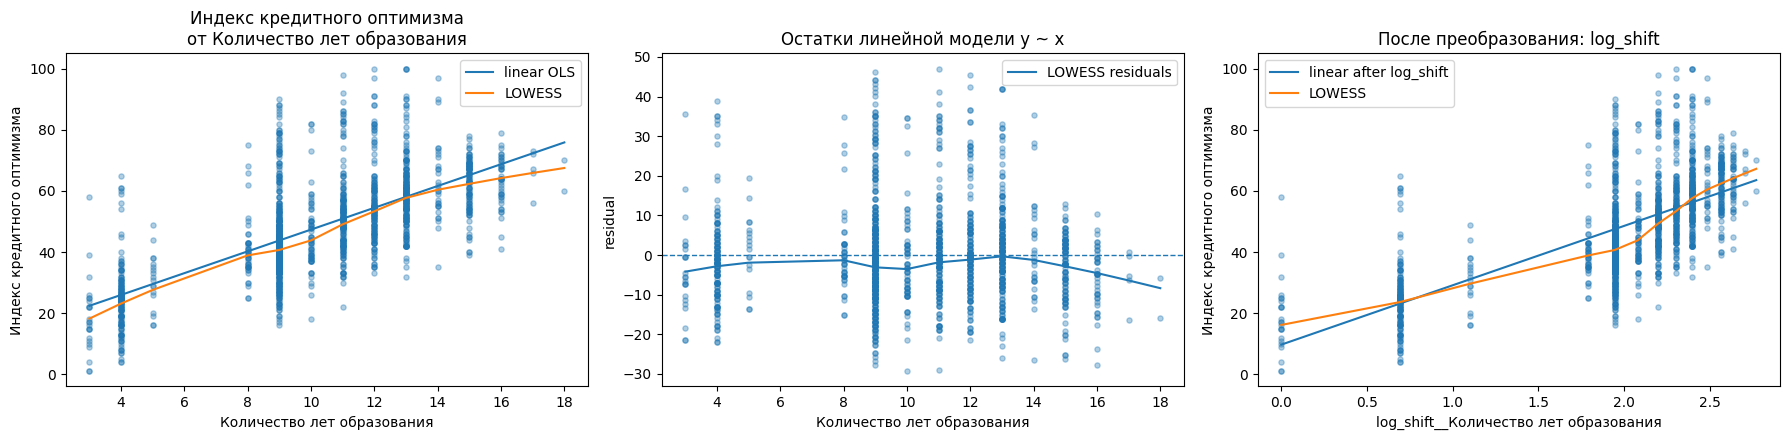

Индекс кредитного оптимизма | Количество лет образования | sqrt_shift | ΔR²=0.0034


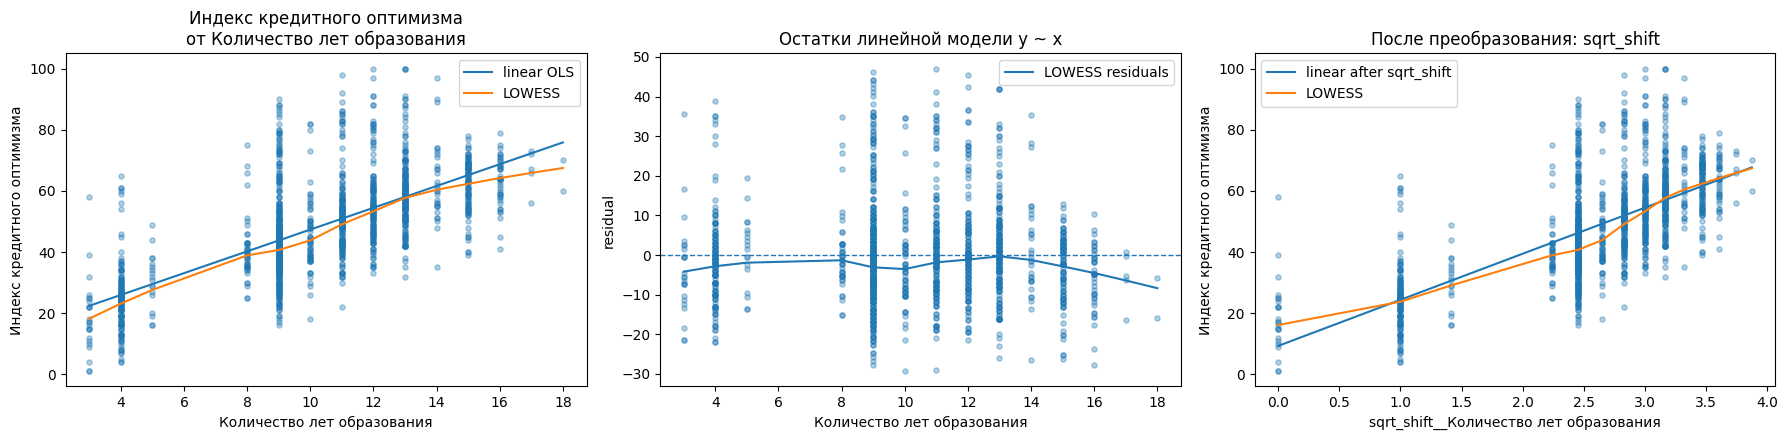

Индекс кредитного оптимизма | Количество лет образования | inv_shift | ΔR²=0.0034


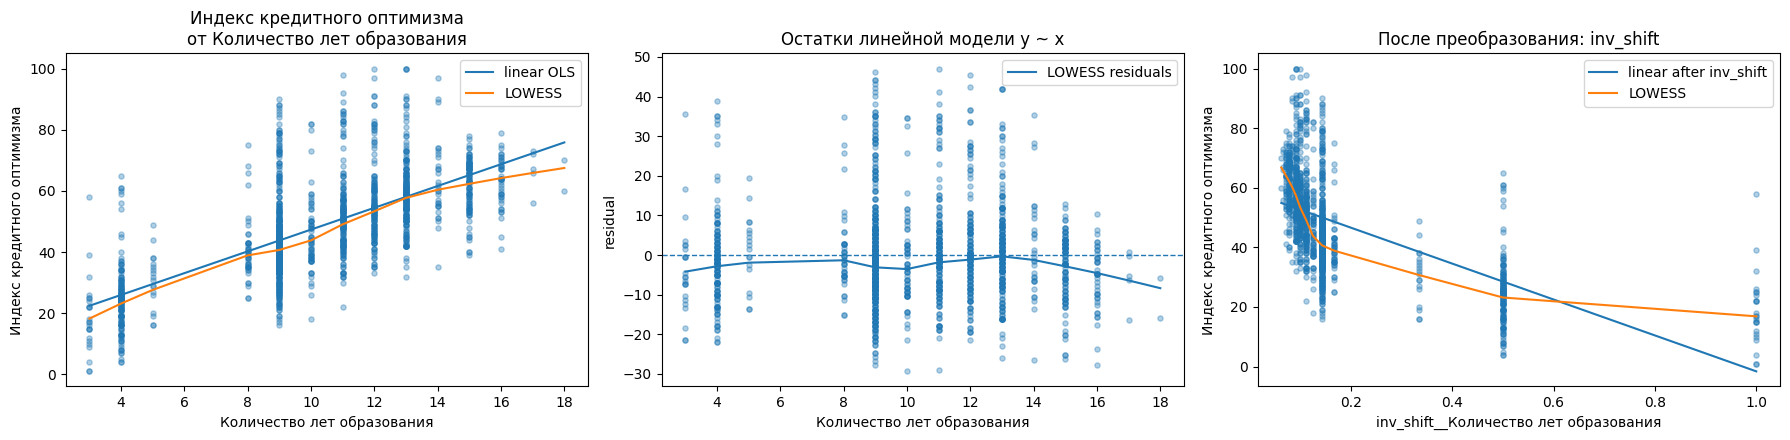

Индекс кредитного оптимизма | Количество лет образования | z4 | ΔR²=0.0031


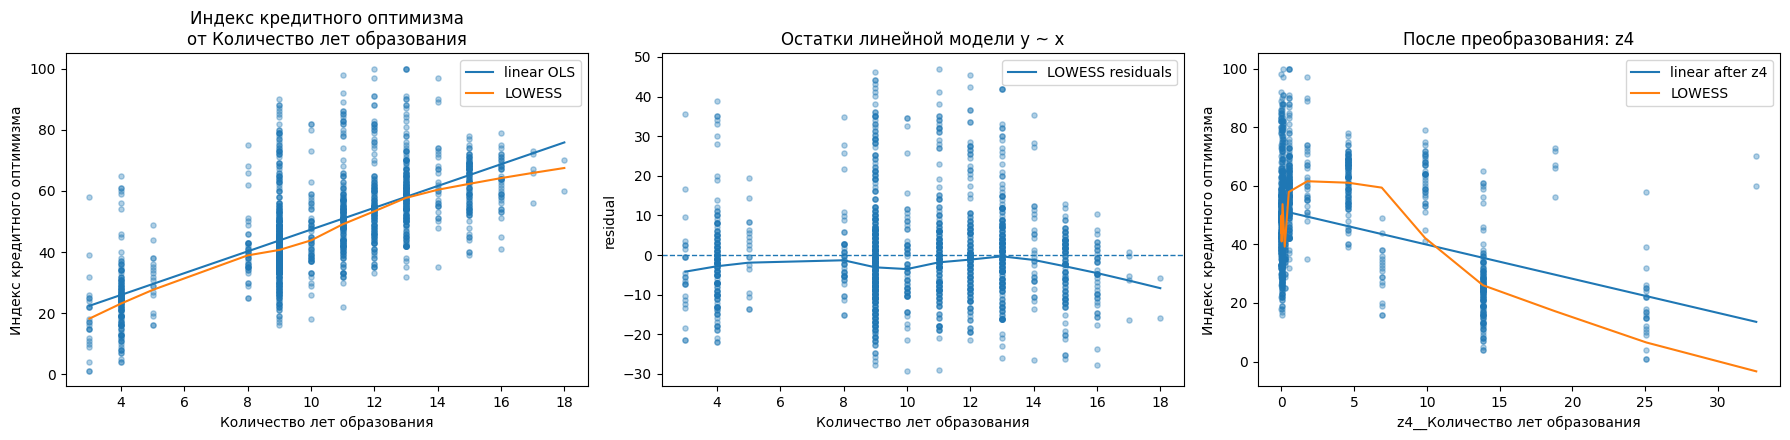

In [8]:

# ============================================================
# 8. Графики нелинейности: scatter, LOWESS, остатки
# ============================================================

def plot_nonlinearity_pair(
    df_part: pd.DataFrame,
    state_col: str,
    cause_col: str,
    transform_kind: str,
    sample_n: int = 2500,
):
    """
    Для пары причина → состояние строит:
    1. scatter + linear OLS + LOWESS;
    2. остатки линейной модели + LOWESS;
    3. зависимость после выбранного преобразования.
    """
    data = df_part[[cause_col, state_col]].dropna().copy()

    if len(data) > sample_n:
        data = data.sample(sample_n, random_state=RANDOM_STATE)

    x = data[cause_col].astype(float).values
    y = data[state_col].astype(float).values

    order = np.argsort(x)
    xs = x[order]

    # Линейная аппроксимация y ~ x
    x_design = np.column_stack([np.ones_like(x), x])
    beta = np.linalg.lstsq(x_design, y, rcond=None)[0]
    y_linear_sorted = beta[0] + beta[1] * xs
    residuals = y - (beta[0] + beta[1] * x)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    # 1. Исходная зависимость
    ax = axes[0]
    ax.scatter(x, y, s=14, alpha=0.35)
    ax.plot(xs, y_linear_sorted, label="linear OLS")

    try:
        smoothed = lowess(y, x, frac=0.35, return_sorted=True)
        ax.plot(smoothed[:, 0], smoothed[:, 1], label="LOWESS")
    except Exception:
        pass

    ax.set_title(f"{state_col}\nот {cause_col}")
    ax.set_xlabel(cause_col)
    ax.set_ylabel(state_col)
    ax.legend()

    # 2. Остатки
    ax = axes[1]
    ax.scatter(x, residuals, s=14, alpha=0.35)
    ax.axhline(0, linestyle="--", linewidth=1)

    try:
        smoothed_resid = lowess(residuals, x, frac=0.35, return_sorted=True)
        ax.plot(smoothed_resid[:, 0], smoothed_resid[:, 1], label="LOWESS residuals")
    except Exception:
        pass

    ax.set_title("Остатки линейной модели y ~ x")
    ax.set_xlabel(cause_col)
    ax.set_ylabel("residual")
    ax.legend()

    # 3. После преобразования
    ax = axes[2]
    params = transform_parameters(data, [cause_col])
    transformed = apply_transform(data, cause_col, transform_kind, params)

    if transformed is None:
        ax.text(0.5, 0.5, "Преобразование неприменимо", ha="center", va="center")
        ax.axis("off")
    else:
        xt = np.asarray(transformed)
        order_t = np.argsort(xt)
        xt_sorted = xt[order_t]

        xt_design = np.column_stack([np.ones_like(xt), xt])
        beta_t = np.linalg.lstsq(xt_design, y, rcond=None)[0]
        y_t_sorted = beta_t[0] + beta_t[1] * xt_sorted

        ax.scatter(xt, y, s=14, alpha=0.35)
        ax.plot(xt_sorted, y_t_sorted, label=f"linear after {transform_kind}")

        try:
            smoothed_t = lowess(y, xt, frac=0.35, return_sorted=True)
            ax.plot(smoothed_t[:, 0], smoothed_t[:, 1], label="LOWESS")
        except Exception:
            pass

        ax.set_title(f"После преобразования: {transform_kind}")
        ax.set_xlabel(f"{transform_kind}__{cause_col}")
        ax.set_ylabel(state_col)
        ax.legend()

    plt.tight_layout()
    plt.show()


if len(single_transform_table) > 0:
    plot_rows = (
        single_transform_table
        .query("delta_R2 > 0")
        .head(N_LOWESS_PLOTS)
    )

    for _, row in plot_rows.iterrows():
        print(
            f"{row['state']} | {row['cause']} | "
            f"{row['transform']} | ΔR²={row['delta_R2']:.4f}"
        )
        plot_nonlinearity_pair(
            df_train,
            state_col=row["state"],
            cause_col=row["cause"],
            transform_kind=row["transform"],
        )


In [14]:

# ============================================================
# 9. МНК: причины → предсказанные состояния
# ============================================================

def fit_state_models_and_predict(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    unknown_df: pd.DataFrame,
    state_cols: list[str],
    transforms_by_state: dict,
):
    """
    Для каждого состояния:
    - строит OOF-прогноз на train;
    - обучается на train;
    - прогнозирует test и unknown.
    """
    pred_train = pd.DataFrame(index=train_df.index)
    pred_test = pd.DataFrame(index=test_df.index)
    pred_unknown = pd.DataFrame(index=unknown_df.index)

    state_rows = []

    for state_col in state_cols:
        specs = transforms_by_state.get(state_col, [])

        X_train = make_state_design_matrix(
            train_df,
            train_df,
            transform_specs=specs,
        )
        y_train = train_df[state_col].astype(float).values

        model = make_linear_pipeline()

        oof_pred = cross_val_predict(
            model,
            X_train,
            y_train,
            cv=make_inner_cv_splits(train_df),
        )
        pred_train[state_col] = oof_pred

        model.fit(X_train, y_train)

        X_test = make_state_design_matrix(
            train_df,
            test_df,
            transform_specs=specs,
            columns=X_train.columns.tolist(),
        )
        X_unknown = make_state_design_matrix(
            train_df,
            unknown_df,
            transform_specs=specs,
            columns=X_train.columns.tolist(),
        )

        pred_test[state_col] = model.predict(X_test)

        if len(unknown_df) > 0:
            pred_unknown[state_col] = model.predict(X_unknown)

        state_rows.append({
            "state": state_col,
            "n_transforms": len(specs),
            "transforms": "; ".join([f"{k}__{c}" for c, k in specs]),
            "OOF_R2": r2_score(y_train, oof_pred),
        })

    state_quality_table = (
        pd.DataFrame(state_rows)
        .sort_values("OOF_R2", ascending=False)
        .reset_index(drop=True)
    )

    return pred_train, pred_test, pred_unknown, state_quality_table


pred_states_train, pred_states_test, pred_states_unknown, state_quality_table = fit_state_models_and_predict(
    df_train,
    df_test,
    df_unknown,
    FINAL_STATES,
    selected_transforms_by_state,
)

print("Качество восстановления состояний:")
display(state_quality_table.round(2))


Качество восстановления состояний:


,state,n_transforms,transforms,OOF_R2
0,Оценка социальной поддержки,0,,0.93
1,Индекс продовольственной безопасности,0,,0.93
2,Индекс кредитного оптимизма,0,,0.92
3,Чувство технологического прогресса,0,,0.90
4,Индекс семьи,0,,0.47
5,Чувство неравенства доходов в обществе,0,,0.14


In [15]:

# ============================================================
# 10. Логистическая регрессия: predicted states / causes / sphere / community
# ============================================================

CLASSIFIER_CONFIGS = {
    "predicted_states": {
        "use_pred_states": True,
        "add_causes": False,
        "use_sphere": False,
        "use_community": False,
    },
    "predicted_states + causes": {
        "use_pred_states": True,
        "add_causes": True,
        "use_sphere": False,
        "use_community": False,
    },
    "predicted_states + causes + sphere": {
        "use_pred_states": True,
        "add_causes": True,
        "use_sphere": True,
        "use_community": False,
    },
    "predicted_states + causes + community": {
        "use_pred_states": True,
        "add_causes": True,
        "use_sphere": False,
        "use_community": True,
    },
    "predicted_states + causes + sphere + community": {
        "use_pred_states": True,
        "add_causes": True,
        "use_sphere": True,
        "use_community": True,
    },
    "causes + sphere + community": {
        "use_pred_states": False,
        "add_causes": True,
        "use_sphere": True,
        "use_community": True,
    },
}

if not COMPARE_CLASSIFIER_CONFIGS:
    CLASSIFIER_CONFIGS = {
        "manual_config": {
            "use_pred_states": USE_PREDICTED_STATES_IN_CLASSIFIER,
            "add_causes": ADD_CAUSES_TO_CLASSIFIER,
            "use_sphere": USE_SPHERE_IN_CLASSIFIER,
            "use_community": USE_COMMUNITY_IN_CLASSIFIER,
        }
    }


def evaluate_classifier_config(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    pred_train: pd.DataFrame,
    pred_test: pd.DataFrame,
    config_name: str,
    config: dict,
):
    """Перебирает C и class_weight для одной конфигурации признаков."""
    rows = []

    X_train = make_classifier_matrix(
        train_df,
        train_df,
        pred_train,
        **config,
    )
    X_test = make_classifier_matrix(
        train_df,
        test_df,
        pred_test,
        columns=X_train.columns.tolist(),
        **config,
    )

    y_train = train_df["rank"].values
    y_test = test_df["rank"].values

    for C, class_weight in product(LOGREG_C_GRID, LOGREG_CLASS_WEIGHT_GRID):
        model = make_logreg_pipeline(C=C, class_weight=class_weight)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        rows.append({
            "config": config_name,
            "C": C,
            "class_weight": str(class_weight),
            "micro_precision": precision_score(y_test, y_pred, average="micro"),
            "accuracy": accuracy_score(y_test, y_pred),
            "model": model,
            "columns": X_train.columns.tolist(),
            "y_pred": y_pred,
            "feature_config": config,
        })

    return rows


classifier_rows = []

for config_name, config in CLASSIFIER_CONFIGS.items():
    classifier_rows.extend(
        evaluate_classifier_config(
            df_train,
            df_test,
            pred_states_train,
            pred_states_test,
            config_name,
            config,
        )
    )

classifier_results_full = pd.DataFrame(classifier_rows)
classifier_results = (
    classifier_results_full
    .drop(columns=["model", "columns", "y_pred", "feature_config"])
    .sort_values("micro_precision", ascending=False)
    .reset_index(drop=True)
)

display(classifier_results.head(20).round(2))

best_idx = classifier_results_full["micro_precision"].idxmax()
best_result = classifier_results_full.loc[best_idx].to_dict()

print("\nЛучшая конфигурация:")
print("config:", best_result["config"])
print("C:", best_result["C"])
print("class_weight:", best_result["class_weight"])
print("micro precision:", round(best_result["micro_precision"], 2))
print("accuracy:", round(best_result["accuracy"], 2))


,config,C,class_weight,micro_precision,accuracy
0,predicted_states + causes + community,3.0,None,0.59,0.59
1,predicted_states + causes + sphere + community,10.0,None,0.58,0.58
2,predicted_states + causes,0.3,None,0.58,0.58
3,predicted_states + causes + community,10.0,None,0.58,0.58
4,predicted_states + causes + sphere + community,3.0,None,0.58,0.58
5,predicted_states + causes,3.0,None,0.58,0.58
6,predicted_states + causes + community,1.0,None,0.58,0.58
7,predicted_states + causes,0.1,None,0.58,0.58
8,predicted_states + causes + community,0.1,None,0.58,0.58
9,predicted_states + causes,1.0,None,0.57,0.57



Лучшая конфигурация:
config: predicted_states + causes + community
C: 3.0
class_weight: None
micro precision: 0.59
accuracy: 0.59


Classification report:
              precision    recall  f1-score   support

    Hopeless       0.62      0.72      0.67        54
   Depressed       0.61      0.62      0.61        55
   Suffering       0.46      0.54      0.49        69
   Strugglng       0.44      0.38      0.41        47
      Coping       0.54      0.38      0.45        66
     Just ok       0.44      0.47      0.45        51
  Doing well       0.75      0.85      0.79        66
    Blooming       0.76      0.67      0.71        39
    Thriving       0.77      0.65      0.71        26
  Prospering       1.00      1.00      1.00         2

    accuracy                           0.59       475
   macro avg       0.64      0.63      0.63       475
weighted avg       0.59      0.59      0.58       475



,Hopeless,Depressed,Suffering,Strugglng,Coping,Just ok,Doing well,Blooming,Thriving,Prospering
Hopeless,39,12,2,0,0,1,0,0,0,0
Depressed,19,34,0,0,0,2,0,0,0,0
Suffering,3,1,37,5,7,11,4,1,0,0
Strugglng,0,1,13,18,4,4,2,5,0,0
Coping,2,3,13,8,25,13,1,1,0,0
Just ok,0,5,15,1,5,24,1,0,0,0
Doing well,0,0,1,3,1,0,56,1,4,0
Blooming,0,0,0,4,3,0,5,26,1,0
Thriving,0,0,0,2,1,0,6,0,17,0
Prospering,0,0,0,0,0,0,0,0,0,2


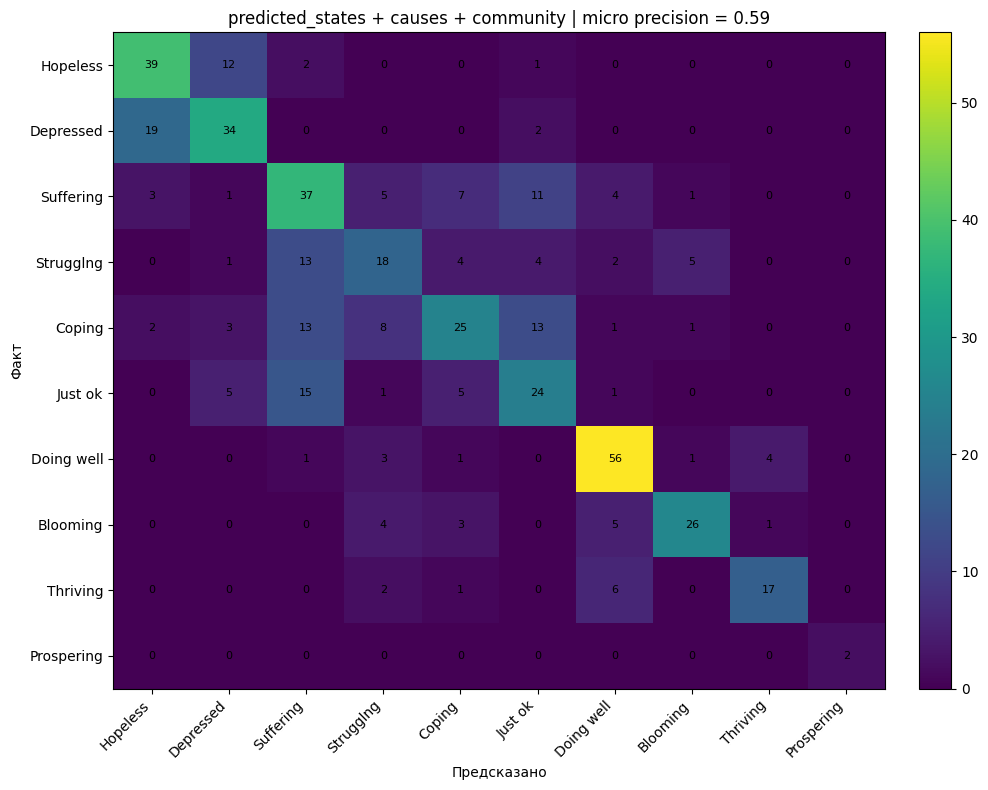

In [11]:

# ============================================================
# 11. Метрики лучшей модели и матрица ошибок
# ============================================================

y_test = df_test["rank"].values
y_pred = best_result["y_pred"]

print("Classification report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=list(range(len(CLASS_ORDER))),
        target_names=CLASS_ORDER,
        zero_division=0,
    )
)

cm = confusion_matrix(y_test, y_pred, labels=list(range(len(CLASS_ORDER))))
cm_df = pd.DataFrame(cm, index=CLASS_ORDER, columns=CLASS_ORDER)

display(cm_df)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, aspect="auto")

ax.set_xticks(np.arange(len(CLASS_ORDER)))
ax.set_yticks(np.arange(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=45, ha="right")
ax.set_yticklabels(CLASS_ORDER)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8)

ax.set_xlabel("Предсказано")
ax.set_ylabel("Факт")
ax.set_title(
    f"{best_result['config']} | "
    f"micro precision = {best_result['micro_precision']:.2f}"
)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [17]:

# ============================================================
# 12. Финальное обучение на всех known и прогноз unknown
# ============================================================

def fit_final_state_models_on_all_known(
    known_df: pd.DataFrame,
    unknown_df: pd.DataFrame,
    state_cols: list[str],
    transforms_by_state: dict,
):
    """
    Для финального файла:
    - OOF-предсказания состояний для known;
    - модели состояний обучены на всех known;
    - предсказания состояний для unknown.
    """
    pred_known = pd.DataFrame(index=known_df.index)
    pred_unknown = pd.DataFrame(index=unknown_df.index)

    rows = []

    for state_col in state_cols:
        specs = transforms_by_state.get(state_col, [])

        X_known = make_state_design_matrix(
            known_df,
            known_df,
            transform_specs=specs,
        )
        y_known = known_df[state_col].astype(float).values

        model = make_linear_pipeline()

        oof_known = cross_val_predict(
            model,
            X_known,
            y_known,
            cv=make_inner_cv_splits(known_df),
        )
        pred_known[state_col] = oof_known

        model.fit(X_known, y_known)

        if len(unknown_df) > 0:
            X_unknown = make_state_design_matrix(
                known_df,
                unknown_df,
                transform_specs=specs,
                columns=X_known.columns.tolist(),
            )
            pred_unknown[state_col] = model.predict(X_unknown)

        rows.append({
            "state": state_col,
            "OOF_R2_all_known": r2_score(y_known, oof_known),
            "transforms": "; ".join([f"{k}__{c}" for c, k in specs]),
        })

    return pred_known, pred_unknown, pd.DataFrame(rows)


pred_states_known_all, pred_states_unknown_all, final_state_quality = fit_final_state_models_on_all_known(
    df_known,
    df_unknown,
    FINAL_STATES,
    selected_transforms_by_state,
)

final_config = best_result["feature_config"]

X_known_final = make_classifier_matrix(
    df_known,
    df_known,
    pred_states_known_all,
    **final_config,
)

X_unknown_final = make_classifier_matrix(
    df_known,
    df_unknown,
    pred_states_unknown_all,
    columns=X_known_final.columns.tolist(),
    **final_config,
)

final_classifier = make_logreg_pipeline(
    C=float(best_result["C"]),
    class_weight=None if best_result["class_weight"] == "None" else "balanced",
)
final_classifier.fit(X_known_final, df_known["rank"].values)

unknown_rank_pred = final_classifier.predict(X_unknown_final)
unknown_label_pred = [rank_to_class[int(r)] for r in unknown_rank_pred]

result_df = df.copy()
result_df.loc[df_unknown.index, TARGET_COL] = unknown_label_pred

# Контроль: known остаются известными, unknown заполнены прогнозом.
print("Прогноз unknown:")
display(pd.Series(unknown_label_pred).value_counts().rename("n").to_frame())

# Сохраняем результаты.
result_df.to_excel(OUTPUT_PREDICTIONS_XLSX, index=False)

with pd.ExcelWriter(OUTPUT_DIAGNOSTICS_XLSX) as writer:
    spearman_table.to_excel(writer, sheet_name="spearman_states", index=False)
    community_summary.to_excel(writer, sheet_name="communities", index=False)
    single_transform_table.to_excel(writer, sheet_name="single_transforms", index=False)
    greedy_transform_table.to_excel(writer, sheet_name="greedy_transforms", index=False)
    state_quality_table.to_excel(writer, sheet_name="state_quality_train", index=False)
    final_state_quality.to_excel(writer, sheet_name="state_quality_all", index=False)
    classifier_results.to_excel(writer, sheet_name="classifier_results", index=False)
    cm_df.to_excel(writer, sheet_name="confusion_matrix")

print("Saved predictions:", OUTPUT_PREDICTIONS_XLSX)
print("Saved diagnostics:", OUTPUT_DIAGNOSTICS_XLSX)


Прогноз unknown:


,n
Suffering,102
Doing well,99
Hopeless,73
Coping,70
Just ok,64
Depressed,58
Strugglng,57
Blooming,44
Thriving,30
Prospering,3


Saved predictions: predicted_happiness_clean_flags_full.xlsx
Saved diagnostics: linearization_diagnostics_clean_flags.xlsx


In [18]:
unknown_result_df = df_unknown.copy()
unknown_result_df[TARGET_COL] = unknown_label_pred
unknown_result_df["predicted_rank"] = unknown_rank_pred

for state_col in FINAL_STATES:
    unknown_result_df[f"pred_state__{state_col}"] = pred_states_unknown_all[state_col].values

print(f"Количество unknown-наблюдений в итоговой таблице: {len(unknown_result_df)}")

unknown_result_df.to_excel(OUTPUT_UNKNOWNS_XLSX, index=False)

Количество unknown-наблюдений в итоговой таблице: 600



## Как интерпретировать результаты

Главные таблицы:

1. `spearman_table` — какие состояния сильнее связаны со счастьем.
2. `single_transform_table` — какие одиночные нелинейные функции повышают `OOF R²`.
3. `greedy_transform_table` — какие функции реально оставлены после жадного отбора.
4. `state_quality_table` — насколько хорошо состояния восстанавливаются по причинам.
5. `classifier_results` — какая схема классификатора дала максимальный `micro precision`.
6. `cm_df` — матрица ошибок лучшей модели.

Что писать в отчёте:

- `community_id` нужен, потому что общественные признаки постоянны внутри сообщества.
- `Сфера занятости` кодируется как категориальный фактор через dummy-переменные.
- Линеаризация применяется не ко всем признакам подряд, а только если она увеличивает `OOF R²`.
- Регуляризация в логистической регрессии управляется параметром `C`.
- Сравнение нескольких конфигураций показывает, какие блоки признаков реально повышают `micro precision`.
